- Add the minus inverse matrix and the Connection matrix r_mean_df above
- Collapse proteins into 1 module for bcl, jak, instead of bcl1, bcl2, just bcl
- Include all inhibitors, e.g. mTOR inhibitors. It is the top 4 and bottom 4 modules, the more drugs, the better
- The graph below should converge, but it might be a mathematical error, no need for iterations
- Take the drugs for the matrix not the modules

In [2]:
import pandas as pd
import numpy as np
import os
import cstarpy.inference
import cstarpy.integration
from cstarpy.preprocessing import PerturbationMagnitude
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
import openpyxl

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
# R_global_annotated = R_global_core.csv  (modules × drugs)
# R_global_DPDonly = DPD response row    (DPD × drugs)
# pert_modules = pert_matrix.csv     (modules × drugs)
# forbidden_connections = built in-code (no Excel sheet)

CD8_DIR = "/mnt/R0/Projects/POIAZ/snugent/Notebooks/output_folder/CD8_Created_Files"


R_global_core_df = pd.read_csv("02_outputs/R_global_core_top4_bottom4.csv", index_col=0)
R_global_DPD_df = pd.read_csv("02_outputs/R_global_DPDonly_top4_bottom4.csv", index_col=0)

modules_core = R_global_core_df.index.tolist()
modules_DPD = R_global_DPD_df.index.tolist()

exp_ids = R_global_core_df.columns.tolist()

#R_global = R_global_df.values
#n_modules = R_global.shape[0]

#print(R_global.shape)
#display(R_global_df)
pert_modules_df = pd.read_csv("02_outputs/pert_matrix_top4_bottom4.csv", index_col=0)

In [4]:
out_dir = "02_outputs"

G_not_df = pd.DataFrame(False, index=modules_core, columns=modules_core)
np.fill_diagonal(G_not_df.values, True)
r_mean_br = cstarpy.inference.run_mra(
            R_global_core_df.values,
            pert_modules_df.values,
            G_not=G_not_df.values,
            method='br',
            pvalue_threshold=0.05)

r_mean_br_df = pd.DataFrame(r_mean_br, index = modules_core, columns = modules_core)
np.fill_diagonal(r_mean_br_df.values, -1) 
r_mean_br_df

  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 203.61it/s]


,ARFGAP,BCL,IGF1R,JAK,MTOR,NAE,SERCA
ARFGAP,-1.00000,0.0,0.000000,0.000000,0.000000,0.0,0.000000
BCL,0.00000,-1.0,0.000000,0.000000,0.000000,0.0,0.225883
IGF1R,0.00000,0.0,-1.000000,0.002282,0.000000,0.0,0.000000
JAK,0.00000,0.0,0.839195,-1.000000,0.536559,0.0,0.000000
MTOR,0.00000,0.0,0.000000,0.002051,-1.000000,0.0,0.000000
NAE,0.36334,0.0,0.000000,0.000000,0.000000,-1.0,0.901881
SERCA,0.00000,0.0,0.000000,0.000000,0.000000,0.0,-1.000000


In [5]:
rp = PerturbationMagnitude(R=R_global_core_df, pert=pert_modules_df, r=r_mean_br_df)
rp.estimate(alpha=1.0)

n_iter = 1200

rps_diff, r_mean, rp_final= cstarpy.inference.run_mra_rp(
            R_global_core_df,
            pert_modules_df,
            G_not=G_not_df.values,
            method='ols',
            pvalue_threshold=0.05,
            alpha=10.0,
            rp_init=rp,
            rp_relax=0.005,
            show_progress_bar=True,
            n_iter=n_iter)

r_mean_df = pd.DataFrame(r_mean, index = modules_core, columns = modules_core)
np.fill_diagonal(r_mean_df.values, -1) 

100%|██████████| 1200/1200 [00:33<00:00, 36.19it/s]


In [6]:
r_mean_df = pd.DataFrame(r_mean, index = modules_core, columns = modules_core)
np.fill_diagonal(r_mean_df.values, -1) 

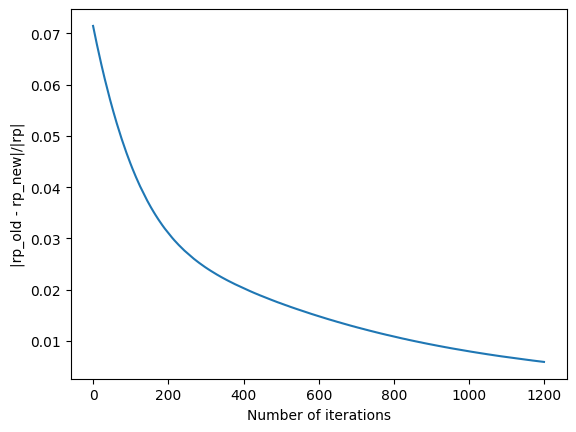

In [7]:
import pylab as plt
plt.plot(np.arange(n_iter),rps_diff)
plt.xlabel('Number of iterations')
plt.ylabel('|rp_old - rp_new|/|rp|')
plt.show()

In [8]:
rps_diff[-1]/np.linalg.norm(rp.df,ord='fro')
print(np.min(rps_diff/np.linalg.norm(rp.df,ord='fro')))
print(np.argmin(rps_diff/np.linalg.norm(rp.df,ord='fro')))

0.0010299881257596125
1199


In [ ]:
COMPOUND_FILE = "/mnt/R0/Projects/POIAZ/snugent/Notebooks/output_folder/CD8_Created_Files/cd8_limma_merged_filtered_targets_ic50_dpd.csv"

df = pd.read_csv(COMPOUND_FILE)
df_avg = (
    df.groupby(["compound_name", "gene"])
    .agg(logFC=("logFC", "mean"), adj_P_Val=("adj.P.Val", "mean"))
    .reset_index()
)
df_avg["logFC_thresh"] = np.where(df_avg["adj_P_Val"] < 0.05, df_avg["logFC"], 0)

pivot = df_avg.pivot_table(index="compound_name", columns="gene",
                            values="logFC_thresh", aggfunc="first").fillna(0)

BTLA_REF_FILE = "/home/snugent/snugent/Notebooks/BTLAvsTCR_24h.csv"
BTLA_REF_COL  = "stat"

btla_ref = pd.read_csv(BTLA_REF_FILE)
btla_ref["gene"] = btla_ref["gene"].astype(str).str.strip()
btla_ref = btla_ref.set_index("gene")

common_genes_btla   = pivot.columns.intersection(btla_ref.index)
pivot_aligned_btla  = pivot[common_genes_btla]
btla_ref_aligned    = btla_ref.loc[common_genes_btla, BTLA_REF_COL].values

btla_dpd_vec = pivot_aligned_btla.values @ btla_ref_aligned

btla_df = pd.DataFrame({
    "compound_name" : pivot_aligned_btla.index,
    "btla_dpd"      : btla_dpd_vec.round(4),
}).sort_values("btla_dpd", ascending=False).reset_index(drop=True)

btla_df.to_csv("btla_deg_per_compound_btla.csv", index=False)
print("\n✓ Saved btla_deg_per_compound_btla.csv")


Modules → DPD:
SERCA    -1077.384033
ARFGAP    -468.618988
IGF1R     -424.566010
BCL          0.000000
NAE          0.000000
MTOR         0.000000
JAK        687.661987


In [ ]:
dpd_by_drug = (
    pd.read_csv("02_outputs/R_global_DPDonly_top4_bottom4.csv", index_col=0)
    .loc["DPD"]
)

btla_by_drug = (
    pd.read_csv("btla_deg_per_compound_btla.csv")
    .set_index("compound_name")["btla_dpd"]
)

R_global_core_df = R_global_core_df.reindex(columns=exp_ids)
pert_modules_df  = pert_modules_df.reindex(columns=exp_ids)
R_global_DPD_df  = pd.DataFrame([dpd_by_drug.reindex(exp_ids)], index=["DPD"])
R_global_BTLA_df = pd.DataFrame([btla_by_drug.reindex(exp_ids)], index=["BTLA"])
R_global_fptu_df = pd.concat([R_global_DPD_df, R_global_BTLA_df])

G_not_fptu = pd.DataFrame(False, index=R_global_fptu_df.index, columns=R_global_core_df.index)

r_fptu = cstarpy.inference.run_regularized_mra_fptu(
    data_perturbed=R_global_core_df,
    data_unperturbed=R_global_fptu_df,
    pert=pert_modules_df.values,
    G_not=G_not_fptu.values,
    method='ols',
    threshold=0.1,
    pvalue_threshold=0.4,
    progress_bar='off')

r_fptu_df = pd.DataFrame(r_fptu, index=["DPD", "BTLA"], columns=modules_core)
print("Modules → DPD:")
print(r_fptu_df.loc["DPD"].sort_values().round(3).to_string())
print("\nModules → BTLA:")
print(r_fptu_df.loc["BTLA"].sort_values().round(3).to_string())


In [ ]:
nodes = modules_core + ["DPD", "BTLA"]
r_total_mean = pd.DataFrame(np.zeros((len(nodes), len(nodes))), index=nodes, columns=nodes)
r_total_mean.loc[modules_core, modules_core] = r_mean
r_total_mean.loc["DPD", modules_core] = r_fptu_df.loc["DPD", modules_core].values
r_total_mean.loc["BTLA", modules_core] = r_fptu_df.loc["BTLA", modules_core].values
np.fill_diagonal(r_total_mean.values, -1)
r_total_mean.to_csv(os.path.join(out_dir, "r_mean_ols_rp_fptu_prefinal_btla.csv"))
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_total_mean.values), index=nodes, columns=nodes) * (-1)
rm_minus_inv.to_csv(os.path.join(out_dir, "r_minv_ols_rp_fptu_prefinal_btla.csv"))

In [ ]:
print("Connection matrix r (modules + DPD):")
print(r_total_mean.round(3).to_string())

print("\nMinus inverse −r⁻¹ (modules + DPD):")
print(rm_minus_inv.round(3).to_string())


Connection matrix r (modules + DPD):
         ARFGAP    BCL    IGF1R      JAK   MTOR    NAE     SERCA  DPD
ARFGAP   -1.000  0.009   -0.013    0.012 -0.035 -0.005     0.162  0.0
BCL      -0.065 -1.000    0.035   -0.027  0.014 -0.044     0.484  0.0
IGF1R    -0.001 -0.000   -1.000    0.002  0.000  0.000    -0.001  0.0
JAK       0.720  0.030    1.313   -1.000  0.606  0.367     0.524  0.0
MTOR     -0.016 -0.008    0.085   -0.063 -1.000  0.004     0.092  0.0
NAE       0.414  0.040    0.083   -0.065  0.049 -1.000     0.983  0.0
SERCA     0.131 -0.039   -0.074    0.058 -0.029  0.099    -1.000  0.0
DPD    -468.619  0.000 -424.566  687.662  0.000  0.000 -1077.384 -1.0

Minus inverse −r⁻¹ (modules + DPD):
        ARFGAP     BCL    IGF1R      JAK     MTOR      NAE    SERCA  DPD
ARFGAP   1.054   0.003    0.002    0.024   -0.027    0.024    0.206  0.0
BCL      0.001   0.982   -0.000    0.000    0.000    0.004    0.479  0.0
IGF1R    0.002  -0.000    1.003    0.002    0.001    0.001    0.002  0.0
JAK 

In [ ]:
R_with_dpd = pd.concat([R_global_core_df, R_global_DPD_df])
pert_full  = pert_modules_df.reindex(index=nodes, fill_value=0)   # add DPD row = 0

r_I = R_with_dpd.reindex(index=nodes).fillna(0) * pert_full

R_I_pred = pd.DataFrame(
    rm_minus_inv.values @ r_I.values,
    index=nodes, columns=exp_ids,
)
print("Predicted systems-level response R_I = -r⁻¹ · r_I:")
print(R_I_pred.round(3).to_string())

# Validate: does the network-based prediction match the directly measured response?
observed = R_with_dpd.reindex(index=nodes)
corr = pd.Series(R_I_pred.values.flatten()).corr(pd.Series(observed.values.flatten()))
print(f"\nCorrelation between predicted R_I and observed R: {corr:.3f}")



Predicted systems-level response R_I = -r⁻¹ · r_I:
         QS-11  navitoclax  BMS-536924   AT9283  TG-101348  CYT-387  ruxolitinib  Deforolimus  Temsirolimus  Sapanisertib  Pevonedistat  Thapsigargin
ARFGAP  -1.320      -0.005      -0.003   -0.028     -0.037   -0.033       -0.046        0.044         0.052         0.053        -0.033        -0.360
BCL     -0.001      -1.566       0.000   -0.000     -0.001   -0.000       -0.001       -0.001        -0.001        -0.001        -0.005        -0.839
IGF1R   -0.002       0.000      -1.446   -0.003     -0.004   -0.003       -0.004       -0.002        -0.003        -0.003        -0.002        -0.004
JAK     -1.367      -0.009      -1.905   -1.169     -1.560   -1.373       -1.939       -0.924        -1.089        -1.120        -0.698        -2.192
MTOR     0.073       0.019      -0.003    0.067      0.089    0.079        0.111       -1.570        -1.851        -1.903         0.019        -0.053
NAE     -0.777      -0.005      -0.001   -0.004  